In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [36]:
pd.set_option('display.precision',6)
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

In [37]:
wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_df = pd.read_csv(wine_url, sep=";")
#다중 클래스 분류는 하지 않고
#quality를 7이상 good 아니면 Ordinary로 설정해
#이진분류로 진행하도록 한다.

In [38]:
#로지스틱 회귀는 모델 명에 회귀가 들어가서
#회귀 모델이라 착각할 수 있으나
#분류 모델임에 유의해야한다.

In [39]:
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [40]:
wine_df.shape

(1599, 12)

In [41]:
wine_df.info()
#float64는 수치형 특성
#int64는 수치형 특성이기도 범주형 특성이기도 하다
#어떻게 보느냐에 따라서 달라진다.

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [42]:
wine_df.select_dtypes(include="float").describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


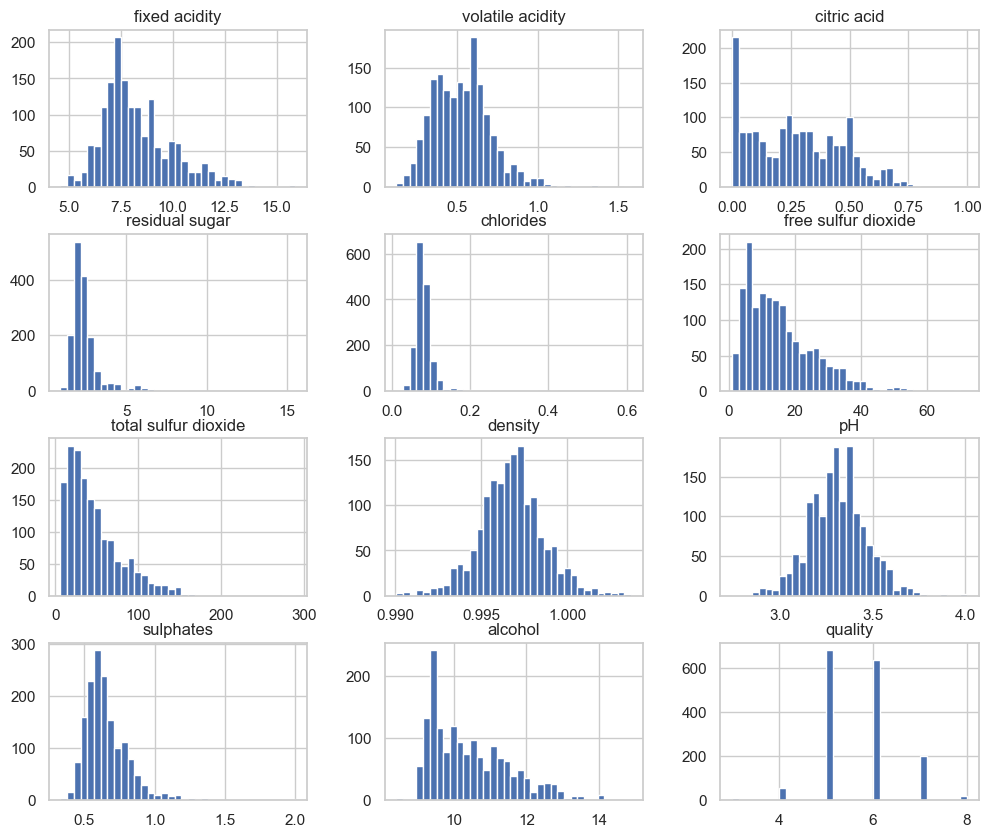

In [43]:
wine_df.hist(bins=35, figsize=(12,10))
plt.show()

In [54]:
wine_df['quality_label'].value_counts(normalize=True)

quality_label
ordinary    0.86429
good        0.13571
Name: proportion, dtype: float64

In [56]:

from sklearn.model_selection import train_test_split

X=wine_df.drop(columns=["quality","quality_label"])
y=wine_df["quality_label"]

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

In [ ]:
quality_label_ratio=pd.DataFrame({
    "Full Dataset":wine_df["quality_label"].value_counts(normalize=True),
    "Train Set":y_train.value_counts(normalize=True),
    "Test Set":y_test.value_counts(normalize=True),
})
quality_label_ratio

,Full Dataset,Train Set,Test Set
quality_label,,,
ordinary,0.86429,0.863956,0.865625
good,0.13571,0.136044,0.134375


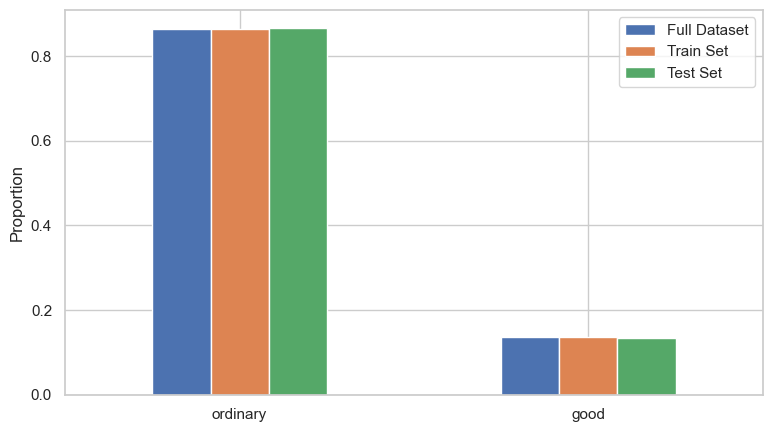

In [63]:
quality_label_ratio.plot.bar(rot=0, figsize=(9,5))

plt.xlabel("")
plt.ylabel("Proportion")
plt.show()

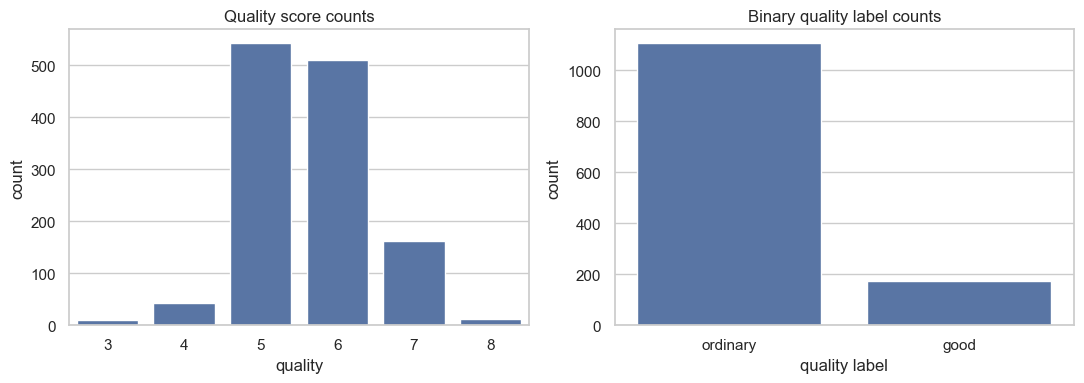

In [64]:
wine_train = X_train.copy()
wine_train["quality"] = wine_df.loc[X_train.index, "quality"]
wine_train["quality_label"] = y_train

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=wine_train, x="quality", ax=axes[0])
axes[0].set_title("Quality score counts")
axes[0].set_xlabel("quality")
axes[0].set_ylabel("count")

sns.countplot(data=wine_train, x="quality_label", order=["ordinary", "good"], ax=axes[1])
axes[1].set_title("Binary quality label counts")
axes[1].set_xlabel("quality label")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

In [67]:
selected_features=[
    "alcohol",
    "volatile acidity",
    "sulphates",
    "density",
]

wine_train[selected_features+["quality", "quality_label"]].head()

,alcohol,volatile acidity,sulphates,density,quality,quality_label
440,9.8,0.31,0.82,0.99870,8,good
1146,9.8,0.50,0.87,0.99600,6,ordinary
229,11.0,0.52,0.50,0.99685,5,ordinary
838,11.2,0.31,0.83,0.99672,7,good
1579,11.3,0.56,0.60,0.99402,5,ordinary


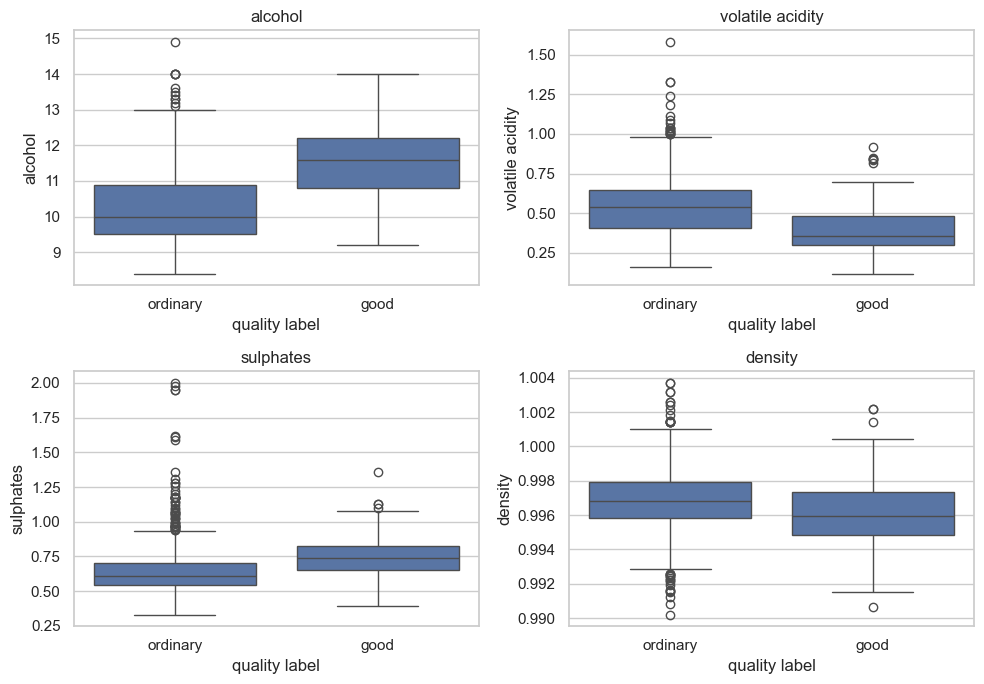

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for feature, ax in zip(selected_features, axes.ravel()):
    sns.boxplot(data=wine_train, x="quality_label", y=feature, order=["ordinary", "good"], ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("quality label")

plt.tight_layout()
plt.show()

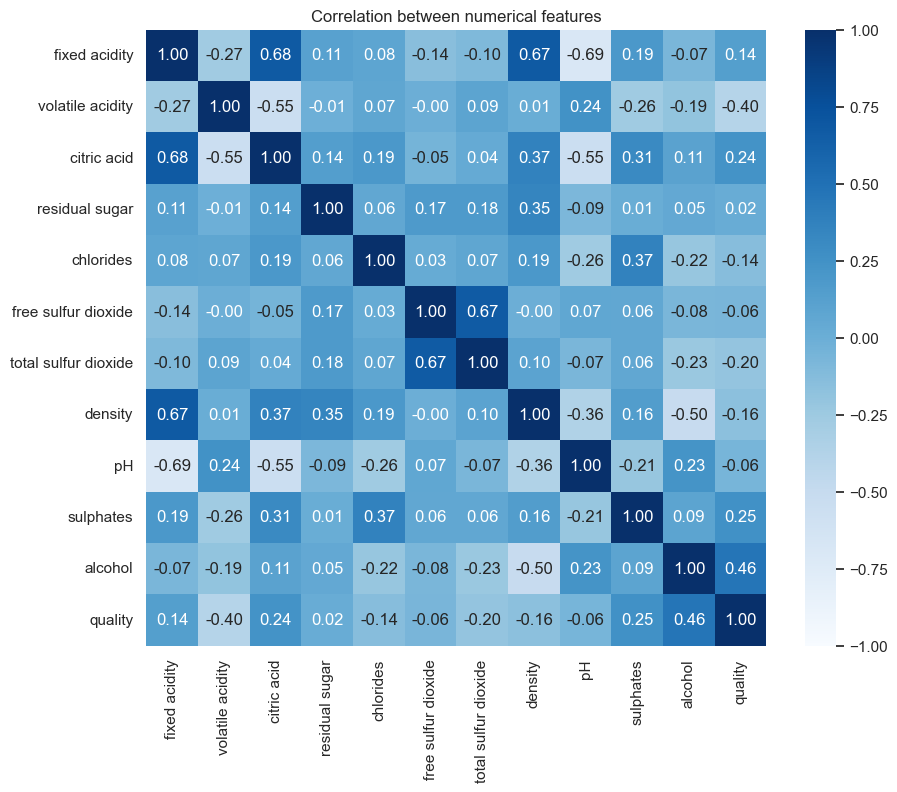

In [71]:
corr = wine_train.drop(columns="quality_label").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between numerical features")
plt.show()

<Axes: xlabel='alcohol', ylabel='residual sugar'>

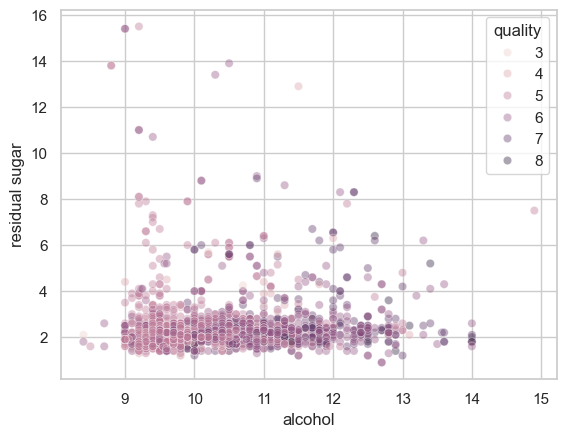

In [44]:
sns.scatterplot(data=wine_df, x="alcohol",y="residual sugar", hue="quality", alpha=0.4)

c:\Users\skato\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Residual Sugar by Alchol')

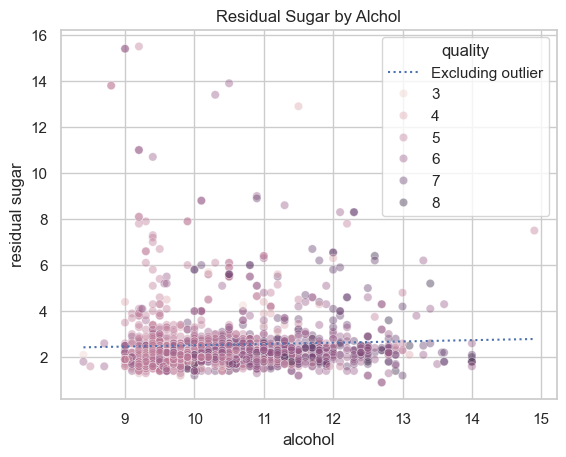

In [45]:
X=wine_df[["alcohol"]]
y=wine_df["residual sugar"]
from sklearn.linear_model import LinearRegression
model = LinearRegression() #기존 데이터 선형회귀
model.fit(X, y)

X_min = wine_df["alcohol"].min()
X_max = wine_df["alcohol"].max()

X_range = np.linspace(X_min, X_max, 200).reshape(-1,1)

#예측값 저장
y_full = model.predict(X_range)

plt.plot(X_range, y_full, "b:", label="Excluding outlier")

sns.scatterplot(data=wine_df, x="alcohol",y="residual sugar", hue="quality", alpha=0.4)

plt.title("Residual Sugar by Alchol")


In [46]:
wine_df["quality_label"] = (wine_df["quality"] >= 7).map({True: "good", False: "ordinary"})

c:\Users\skato\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Residual Sugar by Alchol')

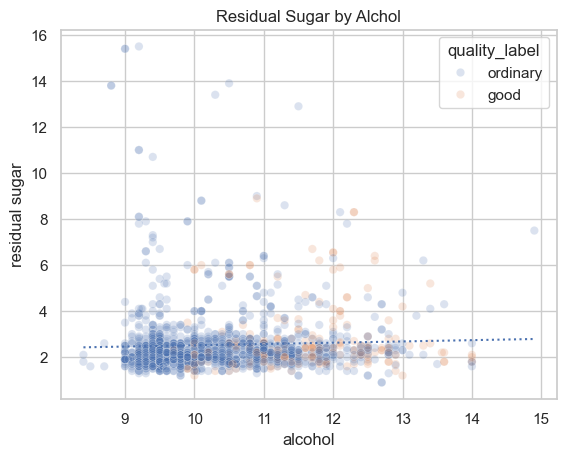

In [47]:
X=wine_df[["alcohol"]]
y=wine_df["residual sugar"]
from sklearn.linear_model import LinearRegression
model = LinearRegression() #기존 데이터 선형회귀
model.fit(X, y)

X_min = wine_df["alcohol"].min()
X_max = wine_df["alcohol"].max()

X_range = np.linspace(X_min, X_max, 200).reshape(-1,1)

#예측값 저장
y_full = model.predict(X_range)

plt.plot(X_range, y_full, "b:")

sns.scatterplot(data=wine_df, x="alcohol",y="residual sugar", hue="quality_label", alpha=0.2)

plt.title("Residual Sugar by Alchol")


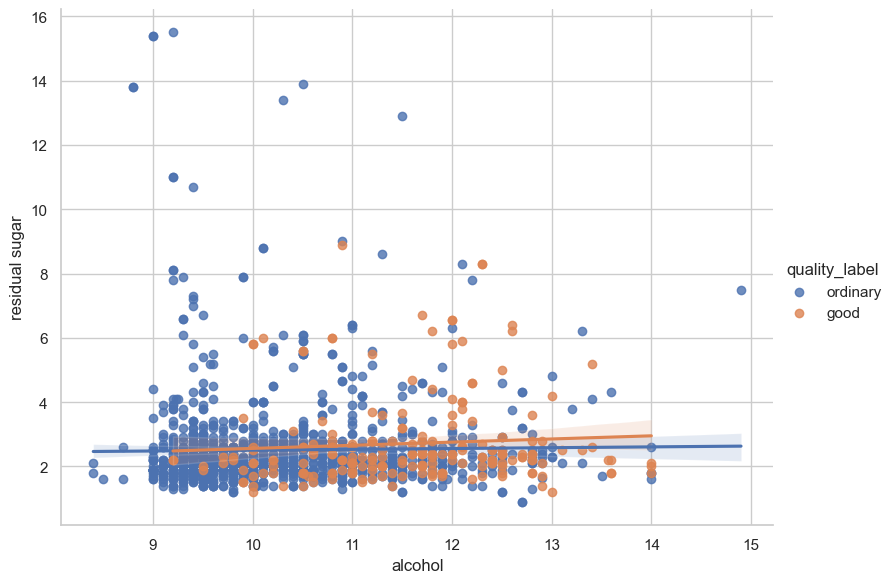

In [31]:
sns.lmplot(data=wine_df, x='alcohol', y='residual sugar', hue='quality_label', height=6, aspect=8/6)
plt.show()

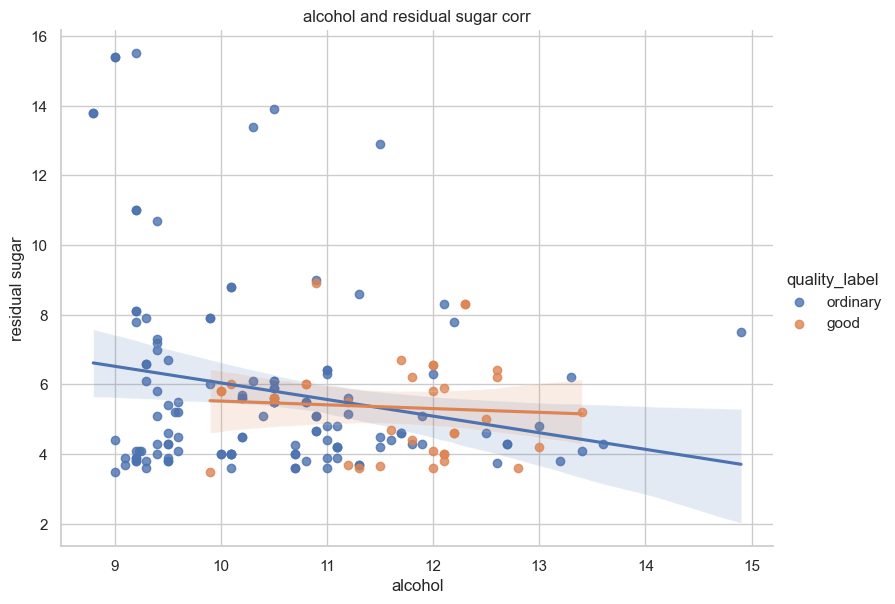

In [77]:
filtered_df = wine_df.loc[wine_df["residual sugar"] >= 3.5]
sns.lmplot(data=filtered_df, x='alcohol', y='residual sugar', hue='quality_label', height=6, aspect=8/6)
plt.title("alcohol and residual sugar corr")
plt.show()

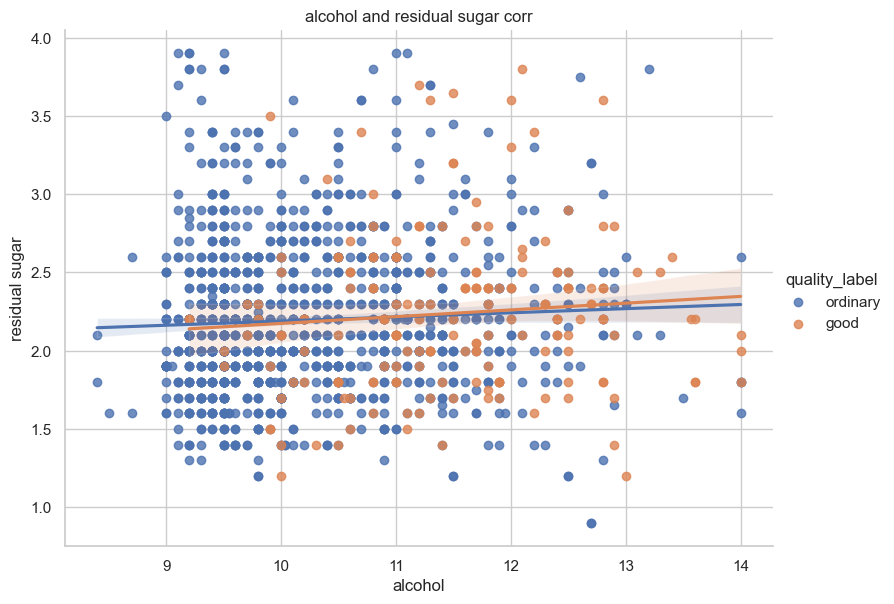

In [52]:
filtered_df = wine_df.loc[wine_df["residual sugar"] < 4]
sns.lmplot(data=filtered_df, x='alcohol', y='residual sugar', hue='quality_label', height=6, aspect=8/6)
plt.title("alcohol and residual sugar corr")
plt.show()